In [2]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


# LOAD DATA

In [2]:
meta=pd.read_excel("/Users/jacobg/Dropbox/shared_leif/Jacob/metadata/all_meta_JG202402.xlsx")
meta_wes = meta.dropna(subset=['wes tumor pre', 'wes tumor sg', 'wes extra FFT'], how='all')
meta_paired = meta_wes.dropna(subset='wes normal').set_index('new name', drop=False)
#bad_samples = ['DFC19_post','MGNS4_post','BIDMC3_post', 'DFC1_post']
bad_samples = ['BIDMC2_pre', 'BIDMC3_post', 'BIDMC4_pre', 'BIDMC4_post', 'BIDMC5_post', 'BIDMC6_pre', 
               'BIDMC6_post', 'BIDMC7_post', 'DFC7_pre_FFT', 'DFC9_pre', 'DFC12_post', 'DFC19_pre', 
               'DFC19_pre', 'DFC20_post', 'DFC23_post', 'MGH3_post', 'MGH5_post', 'MGNS4_pre', 
               'NWH2_pre_FFT', 'MGNS5_post', 'DFC1_pre', 'DFC19_post', 'MGNS4_post', 'BIDMC3_post', 
               'DFC1_post']
for c in ['wes tumor pre', 'wes tumor sg', 'wes extra FFT', 'wes normal']:
    meta_paired[c] = meta_paired[c].replace(bad_samples, np.nan)



tumor_meta = pd.DataFrame({'tumor': pd.concat([meta_paired['wes tumor pre'], meta_paired['wes tumor sg'], meta_paired['wes extra FFT']])}).dropna()
tumor_meta = tumor_meta.reset_index().rename(columns={'new name': 'patient'}).set_index('tumor', drop=False)
tumor_meta['patient'] = ''
tumor_meta['timing'] = ''
tumor_meta['sg_response'] = ''
tumor_meta['final_response'] = ''

for patient in meta_paired.index:
    for signature in ['wes tumor pre', 'wes tumor sg', 'wes extra FFT']:
        tumor = meta_paired.at[patient,signature]
        if pd.isna(tumor):
            continue
        tumor_meta.at[tumor,'patient'] = patient
        tumor_meta.at[tumor,'sg_response'] = meta_paired.at[patient,'post sg response']
        tumor_meta.at[tumor,'final_response'] = meta_paired.at[patient,'final response(surgery)']
        
tumor_meta['final_response_binary'] = tumor_meta['final_response'].apply(lambda x: 'pCR' if x == 'pCR' else 'RD')
tumor_meta['timing'] = tumor_meta['tumor'].apply(lambda x: 'post' if x.endswith("post") else 'pre')
tumor_meta['tissue_type'] = tumor_meta['tumor'].apply(lambda x: 'FFT' if x.endswith("FFT") else 'frozen')
tumor_meta.sort_values(by='patient', axis=0, inplace=True)
tumor_meta.reset_index(drop=True, inplace=True)

display(tumor_meta)
print(tumor_meta.shape)


,patient,tumor,timing,sg_response,final_response,final_response_binary,tissue_type
0,BIDMC1,BIDMC1_pre,pre,RD,RCB-I,RD,frozen
1,BIDMC3,BIDMC3_pre,pre,pCR,pCR,pCR,frozen
2,BIDMC5,BIDMC5_pre,pre,RD,RCB-II,RD,frozen
3,BIDMC7,BIDMC7_pre,pre,RD,RCB-I,RD,frozen
4,BIDMC8,BIDMC8_pre,pre,pCR,pCR,pCR,frozen
5,DFC1,DFC1_pre_FFT,pre,RD,RCB-I,RD,FFT
6,DFC10,DFC10_pre,pre,RD,pCR,pCR,frozen
7,DFC11,DFC11_pre,pre,pCR,pCR,pCR,frozen
8,DFC13,DFC13_post,post,RD,RCB-II,RD,frozen
9,DFC13,DFC13_pre,pre,RD,RCB-II,RD,frozen


(45, 7)


In [3]:
instability = pd.read_csv('/Users/jacobg/Dropbox/shared_leif/Jacob/WES_2024/copynumber/Data/purecn/chromosome_instability.csv')
display(instability)

ploidy = pd.read_csv('/Users/jacobg/Dropbox/shared_leif/Jacob/WES_2024/copynumber/Data/purecn/purity_ploidy/purities.csv')
display(ploidy)

tmb = pd.read_csv('/Users/jacobg/Dropbox/shared_leif/Jacob/WES_2024/somatic/data/TMB.csv', index_col=0)
display(tmb)

,sample,dominant_cin,normal_cin
0,BIDMC1_pre,0.758379,0.994832
1,BIDMC2_pre,0.420390,0.420390
2,BIDMC3_post,0.150417,0.150417
3,BIDMC3_pre,0.818949,0.984388
4,BIDMC4_post,0.188589,0.188589
...,...,...,...
61,MGNS6_pre,0.446005,0.824290
62,NWH1_pre,0.237460,0.237460
63,NWH2_pre_FFT,0.021938,0.021938
64,NWH3_post,0.152752,0.152752


,Sampleid,Purity,Ploidy,Sex,Contamination,Flagged,Failed,Curated,Comment
0,BIDMC1_pre,0.40,4.217635,F,0,False,False,False,NaN
1,BIDMC2_pre,0.18,1.913453,F,0,True,False,False,LOW PURITY
2,BIDMC3_post,0.15,2.055852,Coverage: ? VCF: F,0,True,False,False,LOW PURITY;POOR GOF (73.1%);NOISY LOG-RATIO;HI...
3,BIDMC3_pre,0.23,3.642004,F,0,True,False,False,LOW PURITY
4,BIDMC4_post,0.22,1.961402,F,0,True,False,False,LOW PURITY
...,...,...,...,...,...,...,...,...,...
61,MGNS6_pre,0.21,2.733953,F,0,True,False,False,LOW PURITY
62,NWH1_pre,0.89,2.061801,F,0,True,False,False,POOR GOF (70.8%);HIGH AT- OR GC-DROPOUT
63,NWH2_pre_FFT,0.22,2.030740,Coverage: ? VCF: F,0,True,False,False,LOW PURITY
64,NWH3_post,0.29,2.104554,F,0,True,False,False,LOW PURITY


,Tumor_Sample_Barcode,Count,TMB
1,BIDMC1_pre,99,2.822485
2,BIDMC3_pre,59,1.682087
3,BIDMC5_pre,119,3.392684
4,BIDMC7_pre,49,1.396988
5,BIDMC8_pre,141,4.019903
6,DFC10_pre,114,3.250135
7,DFC11_pre,100,2.850995
8,DFC13_post,24,0.684239
9,DFC13_pre,20,0.570199
10,DFC14_pre,105,2.993545


In [4]:
merged = tumor_meta.merge(instability, how='left', left_on='tumor', right_on='sample').drop(columns=['sample'])
merged = merged.merge(ploidy, how='left', left_on='tumor', right_on='Sampleid').drop(columns=['Sampleid'])
merged = merged.merge(tmb, how='left', left_on='tumor', right_on='Tumor_Sample_Barcode').drop(columns=['Tumor_Sample_Barcode'])
merged


,patient,tumor,timing,sg_response,final_response,final_response_binary,tissue_type,dominant_cin,normal_cin,Purity,Ploidy,Sex,Contamination,Flagged,Failed,Curated,Comment,Count,TMB
0,BIDMC1,BIDMC1_pre,pre,RD,RCB-I,RD,frozen,0.758379,0.994832,0.40,4.217635,F,0,False,False,False,NaN,99,2.822485
1,BIDMC3,BIDMC3_pre,pre,pCR,pCR,pCR,frozen,0.818949,0.984388,0.23,3.642004,F,0,True,False,False,LOW PURITY,59,1.682087
2,BIDMC5,BIDMC5_pre,pre,RD,RCB-II,RD,frozen,0.616504,0.952254,0.45,2.845000,Coverage: ? VCF: F,0,True,False,True,RARE KARYOTYPE,119,3.392684
3,BIDMC7,BIDMC7_pre,pre,RD,RCB-I,RD,frozen,0.295561,0.999969,0.49,2.695807,Coverage: ? VCF: F,0,False,False,False,NaN,49,1.396988
4,BIDMC8,BIDMC8_pre,pre,pCR,pCR,pCR,frozen,0.766988,0.927118,0.41,3.571000,F,0,True,False,True,RARE KARYOTYPE,141,4.019903
5,DFC1,DFC1_pre_FFT,pre,RD,RCB-I,RD,FFT,0.565425,0.646850,0.49,1.755428,F,0,True,False,False,EXCESSIVE LOH,88,2.508876
6,DFC10,DFC10_pre,pre,RD,pCR,pCR,frozen,0.659947,0.886810,0.28,2.456475,Coverage: ? VCF: F,0,True,False,False,LOW PURITY;EXCESSIVE LOH,114,3.250135
7,DFC11,DFC11_pre,pre,pCR,pCR,pCR,frozen,0.754854,0.995046,0.47,4.546733,Coverage: ? VCF: F,0,True,False,False,RARE KARYOTYPE,100,2.850995
8,DFC13,DFC13_post,post,RD,RCB-II,RD,frozen,0.650102,0.779865,0.39,2.556346,F,0,False,False,False,NaN,24,0.684239
9,DFC13,DFC13_pre,pre,RD,RCB-II,RD,frozen,0.704756,0.982732,0.45,3.978683,F,0,False,False,False,NaN,20,0.570199


# PLOT BOX PLOTS (FIG1)

In [5]:
# Filter pre-treatment data
merged_pre = merged[merged['timing']=='pre']

# Function to add t-test annotation to plot
def add_stat_annotation(ax, data, x, y, hue, box_pairs, test='t-test_ind', text_format='star', loc='inside'):
    """
    Add statistical annotation to plot.
    
    Parameters:
    -----------
    ax : matplotlib axes
        The axes where the annotation should be plotted.
    data : DataFrame
        Input data.
    x : str
        Column name for x-axis values.
    y : str
        Column name for y-axis values.
    hue : str
        Column name for group values.
    box_pairs : list of tuples
        Pairs of groups to compare (e.g., [('pCR', 'RD')]).
    test : str, default 't-test_ind'
        Statistical test to use.
    text_format : str, default 'star'
        How to format the annotation ('star', 'p', or 'full').
    loc : str, default 'inside'
        Location of the annotation ('inside' or 'outside').
    """
    # For each box pair, perform a t-test
    for pair in box_pairs:
        group1 = data[data[hue] == pair[0]][x].dropna()
        group2 = data[data[hue] == pair[1]][x].dropna()
        
        # Perform t-test
        stat, pval = stats.ttest_ind(group1, group2, equal_var=False)
        
        # Format the p-value based on the preference
        if text_format == 'star':
            if pval < 0.001:
                text = '***'
            elif pval < 0.01:
                text = '**'
            elif pval < 0.05:
                text = '*'
            else:
                text = 'ns'
        elif text_format == 'p':
            text = f'p={pval:.3f}'
        else:  # 'full'
            text = f't={stat:.2f}, p={pval:.3f}'
        
        # Add the annotation to the plot
        y_pos = max(group1.max(), group2.max()) * 1.1  # Position above the highest point
        x_pos = 0.5  # Middle of the plot
        ax.annotate(text, xy=(x_pos, y_pos), xycoords='data',
                   ha='center', va='Top', fontsize=12)

/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_pre, x='sg_response', y=set[0], whis=True, showfliers=False, order=['pCR', 'RD'], fill=False, palette=palette) # fill=False
/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:10: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(data=merged_pre, x='sg_response', y=set[0], whis=True, showfliers=False, order=['pCR', 'RD'], fill=False, palette=palette) # fill=False
/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.stripplot(data=merged_pre, x='sg_response', y=set[0], hue='sg_response', order=[

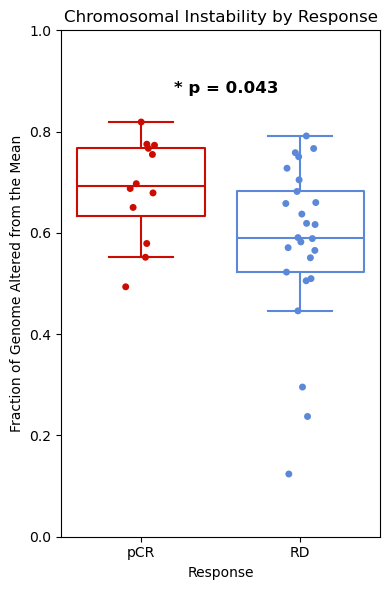

/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_pre, x='sg_response', y=set[0], whis=True, showfliers=False, order=['pCR', 'RD'], fill=False, palette=palette) # fill=False
/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:10: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(data=merged_pre, x='sg_response', y=set[0], whis=True, showfliers=False, order=['pCR', 'RD'], fill=False, palette=palette) # fill=False
/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.stripplot(data=merged_pre, x='sg_response', y=set[0], hue='sg_response', order=[

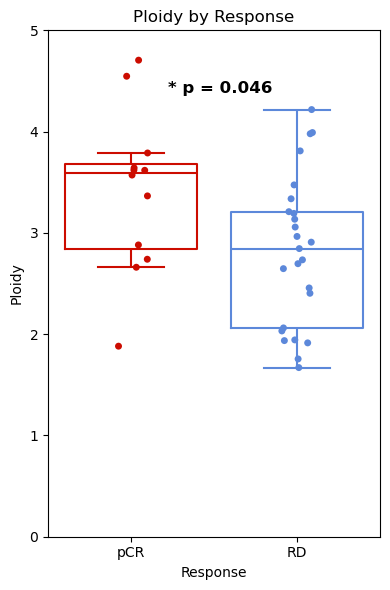

/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=merged_pre, x='sg_response', y=set[0], whis=True, showfliers=False, order=['pCR', 'RD'], fill=False, palette=palette) # fill=False
/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:10: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.boxplot(data=merged_pre, x='sg_response', y=set[0], whis=True, showfliers=False, order=['pCR', 'RD'], fill=False, palette=palette) # fill=False
/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/826245219.py:11: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.stripplot(data=merged_pre, x='sg_response', y=set[0], hue='sg_response', order=[

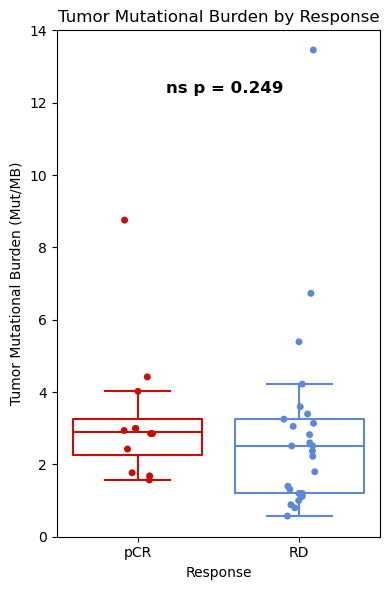

In [6]:
palette=["#CC0C00FF", "#5C88DAFF", "#84BD00FF", "#FFCD00FF"]
path = '/Users/jacobg/Dropbox/shared_leif/neoSTAR A1 manuscript prep/exome_Jacob/plots'


for set in [('dominant_cin', 'Fraction of Genome Altered from the Mean', 'Chromosomal Instability', (0,1)),
            ('Ploidy', 'Ploidy', 'Ploidy',(0,5)),
            ('TMB', 'Tumor Mutational Burden (Mut/MB)', 'Tumor Mutational Burden', (0,14))]:
    plt.figure(figsize=(4, 6)) 
    sns.boxplot(data=merged_pre, x='sg_response', y=set[0], whis=True, showfliers=False, order=['pCR', 'RD'], fill=False, palette=palette) # fill=False
    sns.stripplot(data=merged_pre, x='sg_response', y=set[0], hue='sg_response', order=['pCR', 'RD'], hue_order=['pCR', 'RD'], palette=palette, legend=False)



    # Calculate the t-test
    response_values = merged_pre['sg_response'].unique()
    group1 = merged_pre[merged_pre['sg_response'] == response_values[0]][set[0]].dropna()
    group2 = merged_pre[merged_pre['sg_response'] == response_values[1]][set[0]].dropna()
    #stat, pval = stats.ttest_ind(group1, group2, equal_var=False)
    stat, pval = stats.mannwhitneyu(group1, group2, alternative='two-sided')
    

    # Format text based on p-value
    if pval < 0.001:
        text = '***'
    elif pval < 0.01:
        text = '**'
    elif pval < 0.05:
        text = '*'
    else:
        text = 'ns'

    # # Add text annotation on the plot
    x_max = max(merged_pre['dominant_cin'].max() * 1.05, merged_pre['dominant_cin'].mean() + 3 * merged_pre['dominant_cin'].std())
    plt.text(x_max * 0.5, set[3][1] * 0.9, f'{text} p = {pval:.3f}', fontsize=12, ha='center', va='top', weight='bold' )
    
    # set axes and details
    plt.ylim(set[3][0],set[3][1])
    plt.title(f'{set[2]} by Response')
    plt.xlabel("Response")
    plt.ylabel(set[1])
    #plt.legend(title="Response")
    plt.tight_layout()
    
    # save as pdf
    filename = f"{path}/{set[2].replace(' ', '_')}_by_response.pdf"
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()
  


# PLOT S11A

9     0.704756
12    0.681827
15    0.791452
19    0.637194
26    0.588748
27    0.658014
40    0.446005
43    0.123825
Name: dominant_cin, dtype: float64
8     0.650102
13    0.719238
16    0.598362
20    0.599769
25    0.510887
28    0.677195
41    0.695392
44    0.152752
Name: dominant_cin, dtype: float64
14.0 0.640625


/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/1771589268.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pre_post['timing'] = pd.Categorical(pre_post['timing'], categories=['pre','post'])
/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/1771589268.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pre_post, x='timing', y=set[0], whis=True, showfliers=False, fill=False, palette=palette)


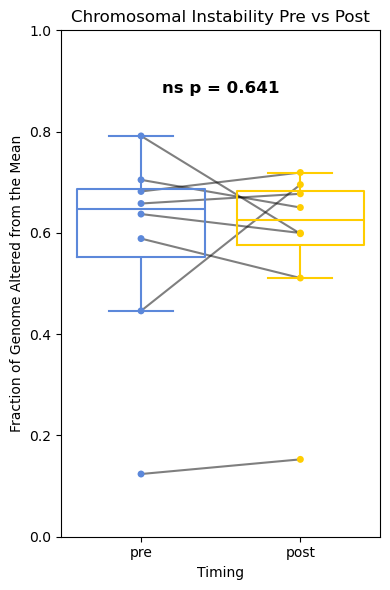

/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/1771589268.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pre_post, x='timing', y=set[0], whis=True, showfliers=False, fill=False, palette=palette)


9     3.978683
12    3.057670
15    3.192548
19    2.646961
26    3.134893
27    3.336835
40    2.733953
43    2.031843
Name: Ploidy, dtype: float64
8     2.556346
13    2.844140
16    3.486797
20    2.724860
25    3.419855
28    3.346863
41    3.565099
44    2.104554
Name: Ploidy, dtype: float64
12.0 0.4609375


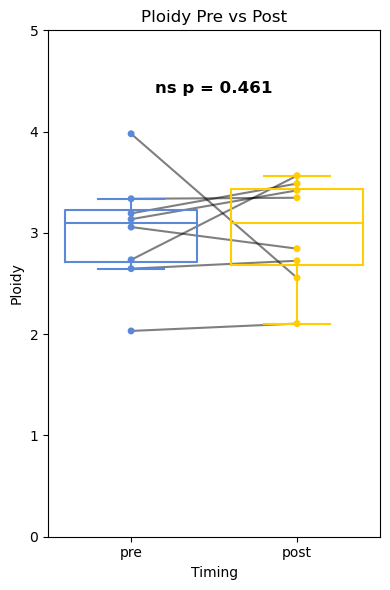

/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_2964/1771589268.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pre_post, x='timing', y=set[0], whis=True, showfliers=False, fill=False, palette=palette)


9     0.570199
12    4.219473
15    6.728349
19    2.223776
26    1.311458
27    1.796127
40    1.197418
43    1.197418
Name: TMB, dtype: float64
8     0.684239
13    3.677784
16    4.818182
20    2.537386
25    1.197418
28    1.254438
41    1.454008
44    1.282948
Name: TMB, dtype: float64
12.0 0.4609375


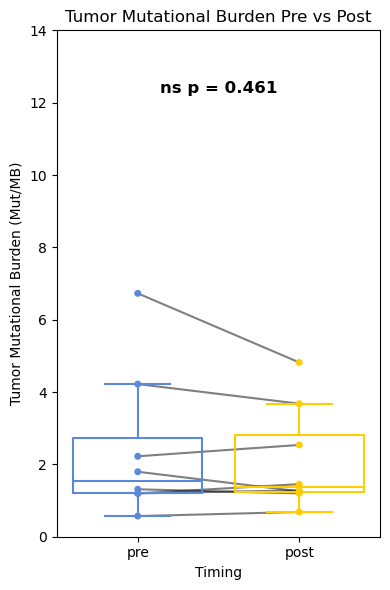

In [29]:
palette=["#5C88DAFF", "#FFCD00FF"]
path = '/Users/jacobg/Dropbox/shared_leif/neoSTAR A1 manuscript prep/exome_Jacob/plots'

# Get patients with both pre and post samples
pre_post_patients = merged[merged['patient'].duplicated()]['patient']
pre_post = merged[merged['patient'].isin(pre_post_patients)]
pre_post['timing'] = pd.Categorical(pre_post['timing'], categories=['pre','post'])

# Loop over the same metrics as your response analysis
for set in [('dominant_cin', 'Fraction of Genome Altered from the Mean', 'Chromosomal Instability', (0,1)),
            ('Ploidy', 'Ploidy', 'Ploidy',(0,5)),
            ('TMB', 'Tumor Mutational Burden (Mut/MB)', 'Tumor Mutational Burden', (0,14))]:
    
    plt.figure(figsize=(4, 6))
    
    # Create the line plot connecting pre/post for each patient
    sns.lineplot(data=pre_post, x='timing', y=set[0], units='patient', estimator=None, color='black', alpha=0.5)
    
    # Add stripplot and boxplot
    sns.stripplot(data=pre_post, x='timing', y=set[0], hue='timing', palette=palette, legend=False, jitter=False)
    sns.boxplot(data=pre_post, x='timing', y=set[0], whis=True, showfliers=False, fill=False, palette=palette)
    
    # Calculate paired statistical test (since these are the same patients)
    pre_values = pre_post[pre_post['timing'] == 'pre'][set[0]].dropna()
    post_values = pre_post[pre_post['timing'] == 'post'][set[0]].dropna()
    
    # Ensure we have paired data
    pre_post_paired = pre_post.dropna(subset=[set[0]]).groupby('patient').filter(lambda x: len(x) == 2)
    if len(pre_post_paired) > 0:
        pre_paired = pre_post_paired[pre_post_paired['timing'] == 'pre'][set[0]]
        post_paired = pre_post_paired[pre_post_paired['timing'] == 'post'][set[0]]
        print(pre_paired)
        print(post_paired)
        
        # Use Wilcoxon signed-rank test for paired samples
        stat, pval = stats.wilcoxon(pre_paired, post_paired, alternative='two-sided')
        print(stat, pval)
        
        # Format text based on p-value
        if pval < 0.001:
            text = '***'
        elif pval < 0.01:
            text = '**'
        elif pval < 0.05:
            text = '*'
        else:
            text = 'ns'
        
        # Add text annotation on the plot
        plt.text(0.5, set[3][1] * 0.9, f'{text} p = {pval:.3f}', fontsize=12, ha='center', va='top', weight='bold')
    
    # Set axes and details
    plt.ylim(set[3][0], set[3][1])
    plt.title(f'{set[2]} Pre vs Post')
    plt.xlabel("Timing")
    plt.ylabel(set[1])
    plt.tight_layout()
    
    # Save as pdf
    filename = f"{path}/{set[2].replace(' ', '_')}_pre_vs_post.pdf"
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)
    
    plt.show()


# PLOT S10 B

In [3]:
new_meta = pd.read_excel('/Users/jacobg/Dropbox/shared_leif/neoSTAR A1 manuscript prep/figures and tables/Table S1_sample_info.xlsx')
new_meta

,Patient_ID,Site_ID,SG_pCR,SG_RCB_value,SG_RCB_cat,Additional_NAC,SG+ANAC_RCB_cat,RD2_group,Survival outcomes [1],Survival notes,Old_RD2_group,WES_blood,WES_pre,WES_post,scRNA_pre,scRNA_post,Orion_pre,Orion_post,GeoMx,Germline mutations
0,P01,MGH1,N,1.468,RCB-II,N,NaN,RD_SG_noANAC,NaN,NaN,"III, remaining RD to SG",N,N,N,N,N,Y,Y,N,NaN
1,P02,DFCI1,N,NaN,NaN,Y,RCB-I,RD_SG+ANAC,NaN,NaN,"II, RD to SG/chemo or with mets(RD2)",Y,Y,N,Y,N,Y,Y,N,NaN
2,P03,MGH2,N,NaN,NaN,Y,RCB-I,RD_SG+ANAC,NaN,NaN,"II, RD to SG/chemo or with mets(RD2)",Y,Y,N,N,N,Y,N,N,BRCA1:c.3084_3094del:p.N1029Rfs*5:Pathogenic
3,P04,MGNS1,N,NaN,NaN,Y,RCB-I,RD_SG+ANAC,NaN,NaN,"II, RD to SG/chemo or with mets(RD2)",N,N,N,N,N,Y,N,N,NaN
4,P05,MGNW1,N,NaN,NaN,Y,RCB-II,RD_SG+ANAC,NaN,NaN,"II, RD to SG/chemo or with mets(RD2)",Y,Y,N,N,N,Y,Y,N,NaN
5,P06,MGH3,Y,0.000,RCB-0,N,NaN,pCR_SG,NaN,NaN,"I, pCR to SG",Y,Y,N,Y,Y,Y,Y,N,"BRCA1:c.C100T:p.Q34X,BRCA1:c.C241T:p.Q81X:Path..."
6,P07,DFCI2,N,1.419,RCB-II,N,NaN,RD_SG_noANAC,NaN,NaN,"III, remaining RD to SG",Y,Y,Y,N,Y,Y,Y,N,NaN
7,P08,MGNW2,N,NaN,NaN,Y,pCR,pCR_SG+ANAC,NaN,NaN,"III, remaining RD to SG",Y,N,N,N,N,Y,Y,N,NaN
8,P09,DFCI3,Y,0.000,RCB-0,N,NaN,pCR_SG,NaN,NaN,"I, pCR to SG",N,N,N,N,N,Y,Y,N,NaN
9,P10,MGH4,N,1.464,RCB-II,N,NaN,RD_SG_noANAC,NaN,NaN,"III, remaining RD to SG",Y,Y,N,N,N,Y,Y,N,NaN


# merge

In [17]:
merged_new = instability.merge(ploidy, how='inner', left_on='sample', right_on='Sampleid')
merged_new = merged_new.merge(tmb, how='inner', left_on='sample', right_on='Tumor_Sample_Barcode')
merged_new['timing'] = merged_new['sample'].apply(lambda x: 'pre' if 'pre' in x else 'post')
merged_new['patient'] = merged_new['sample'].apply(lambda x: x.split('_')[0])
merged_new['Site_ID'] = merged_new['patient'].apply(lambda x: x.replace('DFC', 'DFCI').replace('NWH', 'MGNW'))
merged_new = merged_new.merge(new_meta, how='left', on='Site_ID')

print(merged_new.columns)
merged_new = merged_new.loc[:,['sample','timing','dominant_cin','normal_cin','Purity','Ploidy', 
                               'TMB','Patient_ID','SG_pCR','RD2_group']]
merged_new

Index(['sample', 'dominant_cin', 'normal_cin', 'Sampleid', 'Purity', 'Ploidy',
       'Sex', 'Contamination', 'Flagged', 'Failed', 'Curated', 'Comment',
       'Tumor_Sample_Barcode', 'Count', 'TMB', 'timing', 'patient', 'Site_ID',
       'Patient_ID', 'SG_pCR', 'SG_RCB_value', 'SG_RCB_cat', 'Additional_NAC',
       'SG+ANAC_RCB_cat', 'RD2_group', 'Survival outcomes [1]',
       'Survival notes', 'Old_RD2_group', 'WES_blood', 'WES_pre', 'WES_post',
       'scRNA_pre', 'scRNA_post', 'Orion_pre', 'Orion_post', 'GeoMx',
       'Germline mutations'],
      dtype='object')


,sample,timing,dominant_cin,normal_cin,Purity,Ploidy,TMB,Patient_ID,SG_pCR,RD2_group
0,BIDMC1_pre,pre,0.758379,0.994832,0.40,4.217635,2.822485,P34,N,RD_SG_noANAC
1,BIDMC3_pre,pre,0.818949,0.984388,0.23,3.642004,1.682087,P38,Y,pCR_SG
2,BIDMC5_pre,pre,0.616504,0.952254,0.45,2.845000,3.392684,P42,N,RD_SG+ANAC
3,BIDMC7_pre,pre,0.295561,0.999969,0.49,2.695807,1.396988,P47,N,RD_SG_noANAC
4,BIDMC8_pre,pre,0.766988,0.927118,0.41,3.571000,4.019903,P49,Y,pCR_SG
5,DFC1_pre_FFT,pre,0.565425,0.646850,0.49,1.755428,2.508876,P02,N,RD_SG+ANAC
6,DFC10_pre,pre,0.659947,0.886810,0.28,2.456475,3.250135,P20,N,pCR_SG+ANAC
7,DFC11_pre,pre,0.754854,0.995046,0.47,4.546733,2.850995,P22,Y,pCR_SG
8,DFC13_post,post,0.650102,0.779865,0.39,2.556346,0.684239,P26,N,RD_SG_noANAC
9,DFC13_pre,pre,0.704756,0.982732,0.45,3.978683,0.570199,P26,N,RD_SG_noANAC


# PLOTS

/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_6022/299604366.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=merged_new_pre, x='RD2_group', y=feature, whis=True, showfliers=False, order=cats, fill=False, palette=palette)


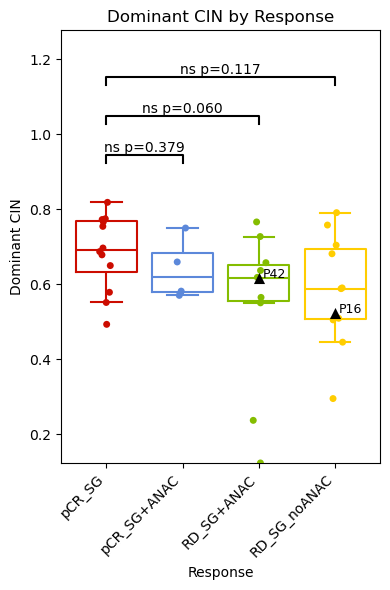

/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_6022/299604366.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=merged_new_pre, x='RD2_group', y=feature, whis=True, showfliers=False, order=cats, fill=False, palette=palette)


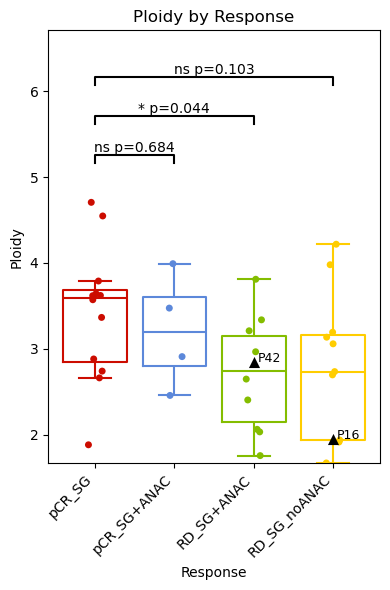

/var/folders/4l/15f8r95x5l7ddlpwz4vddgmc0000gp/T/ipykernel_6022/299604366.py:93: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=merged_new_pre, x='RD2_group', y=feature, whis=True, showfliers=False, order=cats, fill=False, palette=palette)


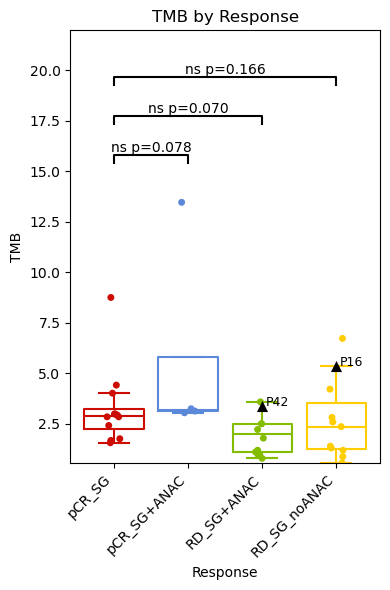

In [28]:
palette=["#CC0C00FF", "#5C88DAFF", "#84BD00FF", "#FFCD00FF"]
path = '/Users/jacobg/Dropbox/shared_leif/neoSTAR A1 manuscript prep/exome_Jacob/plots'
features = ['dominant_cin', 'Ploidy', 'TMB']
cats = ['pCR_SG','pCR_SG+ANAC','RD_SG+ANAC','RD_SG_noANAC']
relapses = ['P16', 'P28', 'P42', 'P50']
merged_new_pre = merged_new[merged_new['timing']=='pre']

# Define plot settings for each feature
plot_settings = {
    'dominant_cin': {'ylabel': 'Dominant CIN','title': 'Dominant CIN by Response'},
    'Ploidy': {'ylabel': 'Ploidy', 'title': 'Ploidy by Response'},
    'TMB': {'ylabel': 'TMB', 'title': 'TMB by Response'}
}


for feature in features:
    plt.figure(figsize=(4, 6))
    ax = sns.boxplot(data=merged_new_pre, x='RD2_group', y=feature, whis=True, showfliers=False, order=cats, fill=False, palette=palette)

    # Separate the data into relapse and non-relapse groups
    relapse_df = merged_new_pre[merged_new_pre['Patient_ID'].isin(relapses)]
    other_df = merged_new_pre[~merged_new_pre['Patient_ID'].isin(relapses)]

    # Plot the non-relapse points as before and relapses with triangle
    sns.stripplot(data=other_df, x='RD2_group', y=feature, hue='RD2_group', order=cats, hue_order=cats, palette=palette, legend=False)
    sns.stripplot(data=relapse_df, x='RD2_group', y=feature, order=cats,marker='^', color='k', s=8, label='Relapse', legend=False, ax=ax)

    # Add text annotations for each relapse point
    for _, row in relapse_df.iterrows():
        try:
            x_coord = cats.index(row['RD2_group'])
            y_coord = row[feature]
            patient_id = row['Patient_ID']
            # Add text with a slight offset to avoid overlapping the marker
            plt.text(x_coord + 0.05, y_coord, patient_id, fontsize=9, ha='left')
        except (ValueError, KeyError):
            # Handle cases where the group or feature might not exist
            pass

    # --- Statistical Tests ---
    control_group = 'pCR_SG'
    experimental_groups = ['pCR_SG+ANAC', 'RD_SG+ANAC', 'RD_SG_noANAC']
    
    y_max = merged_new_pre[feature].max()
    y_min = merged_new_pre[feature].min()
    y_range = y_max - y_min
    y_increment = y_range * 0.15

    for i, exp_group in enumerate(experimental_groups):
        group1 = merged_new_pre[merged_new_pre['RD2_group'] == control_group][feature].dropna()
        group2 = merged_new_pre[merged_new_pre['RD2_group'] == exp_group][feature].dropna()
        stat, pval = stats.mannwhitneyu(group1, group2, alternative='two-sided')

        if pval < 0.001: text = '***'
        elif pval < 0.01: text = '**'
        elif pval < 0.05: text = '*'
        else: text = 'ns'

        x1, x2 = cats.index(control_group), cats.index(exp_group)
        y_pos = y_max + (i + 1) * y_increment
        bar_height = y_increment * 0.2

        plt.plot([x1, x1, x2, x2], [y_pos, y_pos + bar_height, y_pos + bar_height, y_pos], lw=1.5, c='k')
        plt.text((x1 + x2) * 0.5, y_pos + bar_height, f'{text} p={pval:.3f}', ha='center', va='bottom', color='k', fontsize=10)

    plt.ylim(y_min, y_max + (len(experimental_groups) + 1) * y_increment * 1.1)

    settings = plot_settings.get(feature, {})
    plt.title(settings.get('title', f'{feature} by Response'))
    plt.xlabel("Response")
    plt.ylabel(settings.get('ylabel', feature))
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()

    filename = f"{path}/{feature.replace(' ', '_')}_by_response_group2.pdf"
    plt.savefig(filename, format='pdf', bbox_inches='tight', dpi=300)

    plt.show()